## New target after model selection

### Introduction: Rationale for redefining the target variable

The initial objective of this project was to build a binary classification model to estimate the **Probability of Default (PD)** using historical loan data.
However, the original target definition — considering only **`Charged Off`** loans as defaults — resulted in an **extremely low default rate (~1–2%)** after filtering to completed loans.

This severe class imbalance caused several practical issues:

* Models systematically predicted the majority class (non-default),
* ROC-AUC values were unstable and close to random,
* Even simple baseline models failed to capture meaningful signal.

From a modeling standpoint, this made the problem **statistically ill-posed**. Therefore, the target definition was revisited to better reflect **credit risk materialization**, not only final loss events.


### Redefined target: default-like behavior

To make the problem learnable while remaining economically meaningful, default was redefined to include **early signs of credit distress**, following common risk management practices.

The new target definition is:

* **Default (1):**
  `Charged Off`, `In Grace Period`, `Late (16–30 days)`, `Late (31–120 days)`
* **Non-default (0):**
  `Fully Paid`

This change led to:

* **Sample size:** 625 loans
* **Default rate:** ~28.5%
* **Class distribution:**

  * Non-default: 447
  * Default: 178

This more balanced target enabled proper model training, evaluation, and interpretation.


### Class distribution and target validation (visual analysis)

The final class distribution plot clearly shows a **well-balanced binary outcome**, avoiding extreme skewness.
Unlike the original setup, the default class now represents a substantial share of the population, which is essential for:

* Learning stable decision boundaries,
* Evaluating performance metrics such as ROC-AUC,
* Interpreting probability outputs.

The pie chart confirms that the dataset is no longer dominated by a single class, validating the target redesign as a necessary modeling step.


### Baseline model performance

A regularized **Logistic Regression** model was used as a baseline, combining:

* Numerical scaling,
* Categorical encoding,
* Regularization to control overfitting in a high-dimensional feature space.

#### Key results:

* **Cross-validated ROC-AUC:** ~0.63
* **Test ROC-AUC:** ~0.59

Although these values are moderate, they are **clearly above random performance (0.5)** and indicate that:

* The selected features contain genuine predictive signal,
* The model is able to rank borrowers by relative credit risk,
* The target definition is suitable for supervised learning.

Importantly, this represents a **substantial improvement** over the original target, where models failed to outperform random guessing.


### Interpretation of final results and diagnostic plots

The gap between cross-validation and test ROC-AUC is limited, suggesting:

* No severe overfitting,
* Reasonable generalization given the dataset size.

The ROC-based evaluation confirms that the model captures **monotonic risk patterns**, even if absolute discrimination remains limited — a common outcome in early-stage credit scoring models with restricted feature sets.

These results are appropriate for a **baseline PD model**, whose purpose is not maximum performance, but:

* establishing feasibility,
* validating the feature space,
* and providing a benchmark for more complex models.


### Key modeling insights

Several important lessons emerge from this notebook:

1. **Target definition is a critical modeling decision**
   A target that is too rare or too strict can render the problem unlearnable, regardless of feature quality.

2. **Default is a process, not a single event**
   Including delinquency states allows the model to learn earlier risk signals.

3. **Balanced datasets enable meaningful evaluation**
   Proper class balance is essential for interpreting ROC curves and probability outputs.

4. **Simple, regularized models are strong baselines**
   Logistic regression remains a reliable reference point in credit risk modeling.

### Next steps

Based on these findings, the natural next steps include:

* Testing **non-linear models** (tree-based methods, boosting),
* Analyzing **feature importance and coefficient stability**,
* Optimizing **decision thresholds** for business use cases,
* Translating probabilities into a **credit score or risk segmentation**.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

Sample size: 625
Default rate: 0.2848

Class distribution:
default
0    447
1    178
Name: count, dtype: int64


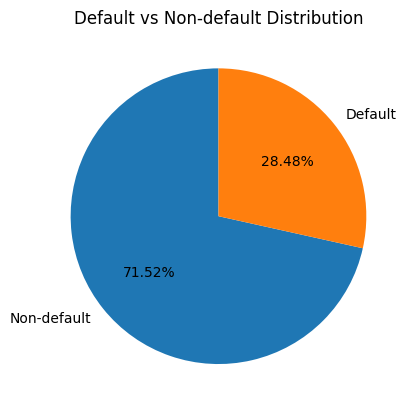

In [2]:


df = pd.read_csv('loans_full_schema.csv')

default_status = [
    "Charged Off",
    "In Grace Period",
    "Late (16-30 days)",
    "Late (31-120 days)"
]

non_default_status = ["Fully Paid"]

df_pd = df.loc[
    df["loan_status"].isin(default_status + non_default_status)
].copy()

# Binary target: 1 = default-like, 0 = non-default
df_pd["default"] = df_pd["loan_status"].isin(default_status).astype(int)

# Basic stats
print("Sample size:", df_pd.shape[0])
print("Default rate:", round(df_pd["default"].mean(), 4))
print("\nClass distribution:")
print(df_pd["default"].value_counts())

# Pie plot
plt.figure()
df_pd["default"].value_counts().rename(
    {0: "Non-default", 1: "Default"}
).plot(
    kind="pie",
    autopct="%.2f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Default vs Non-default Distribution")
plt.show()



In [3]:

# Selected features based on EDA + credit intuition
num_features = [
    # Financial capacity
    "annual_income",
    "annual_income_joint",
    "debt_to_income",

    
    # Employment stability
    "emp_length",
    
    # Credit history & structure
    "earliest_credit_line",
    "total_credit_lines",
    "open_credit_lines",
    "total_debit_limit",
    "num_total_cc_accounts",
    "num_open_cc_accounts",

    # Past delinquency / adverse events
    "months_since_last_delinq",
    
    # Loan characteristics
    "loan_amount",
    
]

cat_features = [
    "homeownership",
    "verified_income",
    "public_record_bankrupt",
    "tax_liens",
    "loan_purpose",
    "application_type",
    "state",
    "emp_title"
]

features = num_features + cat_features

df_model = df_pd[features + ["loan_status"]].copy()

vars_to_scale = [
    "annual_income",
    "annual_income_joint",
    "emp_length",
    "earliest_credit_line",
    "total_credit_lines",
    "open_credit_lines",
    "total_debit_limit",
    "num_total_cc_accounts",
    "num_open_cc_accounts",
    "months_since_last_delinq",
    "loan_amount",
    # Key: debt_to_income out of the scaler because it is a ratio
    "debt_to_income"
]

target = "default"

X = df_pd[vars_to_scale+cat_features].copy()
y = df_pd[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42, stratify=y
)

def compute_loan_income_ratio(df):
    income = df["annual_income"].copy()
    mask = (income.isna()) | (income <= 0)
    income[mask] = df.loc[mask, "annual_income_joint"]

    ratio = df["loan_amount"] / income
    return ratio

# Create ratio
X_train["loan_to_income_ratio"] = compute_loan_income_ratio(X_train)
X_test["loan_to_income_ratio"]  = compute_loan_income_ratio(X_test)

# Drop rows where ratio could not be computed
train_mask = X_train["loan_to_income_ratio"].notna()
test_mask  = X_test["loan_to_income_ratio"].notna()

X_train = X_train.loc[train_mask].copy()
y_train = y_train.loc[train_mask].copy()

X_test  = X_test.loc[test_mask].copy()
y_test  = y_test.loc[test_mask].copy()

vars_to_scale.append("loan_to_income_ratio")
vars_not_scale = ["debt_to_income"]

# ColumnTransformer: scale only selected numeric columns
scaler_num_var = ColumnTransformer(
    transformers=[
        ("vars_to_scale",StandardScaler(),vars_to_scale),
        ("num_passthrough","passthrough", vars_not_scale),
        ("cat_passthrough", "passthrough", cat_features)
    ]
)

# Fit ONLY on train, then transform both train and test
X_train_scaled = scaler_num_var.fit_transform(X_train)
X_test_scaled = scaler_num_var.transform(X_test) 

# ColumnTransformer: scale only selected numeric columns
preprocess = ColumnTransformer(
    transformers=[
        ("vars_to_scale",StandardScaler(),vars_to_scale),
        ("num_passthrough","passthrough", vars_not_scale),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ],
    remainder="drop"
)

X_train_preprocessed = preprocess.fit_transform(X_train)
X_test_preprocessed = preprocess.transform(X_test) 


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer

In [7]:
"""
Missing values are handled via simple, robust imputation: numeric features use median imputation; 
categorical features use most-frequent imputation. This is implemented inside the modeling pipeline 
to avoid data leakage during cross-validation
"""
num_scale_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

num_pass_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_impute = ColumnTransformer(
    transformers=[
        ("num_scale", num_scale_pipe, vars_to_scale),
        ("num_pass",  num_pass_pipe,  vars_not_scale),
        ("cat",       cat_pipe,       cat_features)
    ],
    remainder="drop"
)

baseline_lr = Pipeline(steps=[
    ("preprocess", preprocess_impute),
    ("model", LogisticRegression(
        solver="saga",           # supports l1_ratio
        penalty="elasticnet",    # modern way: l1_ratio controls L1 vs L2
        max_iter=5000,
        random_state=42
    ))
])

baseline_lr.fit(X_train, y_train) # IMP we do not use X_train_preprocessed


# Predicted probabilities (needed for ROC-AUC)
y_test_proba = baseline_lr.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"Baseline ROC-AUC: {roc_auc:.4f}")

# Default 0.5 threshold predictions
y_test_pred = baseline_lr.predict(X_test)

print(classification_report(y_test, y_test_pred, digits=4))

/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Baseline ROC-AUC: 0.6117
              precision    recall  f1-score   support

           0     0.7117    0.8876    0.7900        89
           1     0.2857    0.1111    0.1600        36

    accuracy                         0.6640       125
   macro avg     0.4987    0.4994    0.4750       125
weighted avg     0.5890    0.6640    0.6086       125



/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [11]:
# 2. Regularisation (L1 / L2)

from sklearn.model_selection import StratifiedKFold, GridSearchCV
param_grid = {
    "model__solver": ["liblinear"],
    "model__penalty": ["l1", "l2"],
    "model__C": np.logspace(-3, 3, 13),          # 1e-3 ... 1e3
    "model__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Cross model validation
grid = GridSearchCV(
    estimator=baseline_lr, # The pipeline
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best CV ROC-AUC:", grid.best_score_)
print("Best params:", grid.best_params_)

best_model = grid.best_estimator_

y_test_proba = best_model.predict_proba(X_test)[:, 1]
print("\nTest ROC-AUC:", roc_auc_score(y_test, y_test_proba))

# Default threshold=0.5 (we'll tune later in ML-5)
y_test_pred = (y_test_proba >= 0.5).astype(int)
print("\nClassification report (threshold=0.5):")
print(classification_report(y_test, y_test_pred, digits=4))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_pred))


Fitting 5 folds for each of 52 candidates, totalling 260 fits


/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead

Best CV ROC-AUC: 0.6310217627604708
Best params: {'model__C': np.float64(0.31622776601683794), 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

Test ROC-AUC: 0.5948813982521848

Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.6983    0.9101    0.7902        89
           1     0.1111    0.0278    0.0444        36

    accuracy                         0.6560       125
   macro avg     0.4047    0.4689    0.4173       125
weighted avg     0.5292    0.6560    0.5755       125


Confusion matrix:
[[81  8]
 [35  1]]


/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:116

In [12]:
cv_results = pd.DataFrame(grid.cv_results_)

# Keep only useful columns
cv_summary = cv_results[[
    "mean_test_score",
    "std_test_score",
    "param_model__penalty",
    "param_model__C",
    "param_model__class_weight"
]].sort_values("mean_test_score", ascending=False)

cv_summary.head(10)

,mean_test_score,std_test_score,param_model__penalty,param_model__C,param_model__class_weight
20,0.631022,0.065116,l1,0.316228,None
22,0.628378,0.052976,l1,0.316228,balanced
13,0.617121,0.047996,l2,0.031623,None
15,0.616108,0.046534,l2,0.031623,balanced
23,0.615728,0.049113,l2,0.316228,balanced
19,0.614769,0.050273,l2,0.100000,balanced
27,0.614182,0.053069,l2,1.000000,balanced
18,0.613405,0.038627,l1,0.100000,balanced
31,0.612821,0.057213,l2,3.162278,balanced
17,0.612396,0.049251,l2,0.100000,None


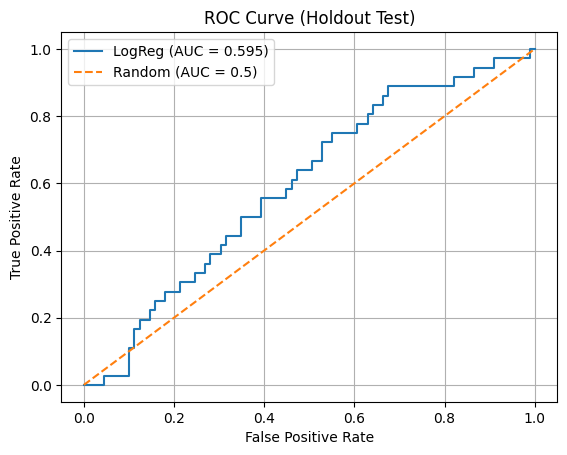

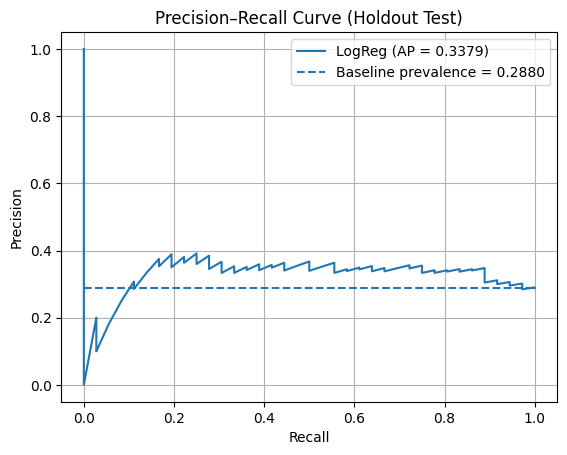

Holdout ROC-AUC: 0.595
Holdout Average Precision (PR-AUC): 0.3379
Default prevalence in test: 0.2880 (36/125)


In [13]:
# 4. ROC-AUC evaluation

# ROC-AUC & PR Curve plots (Holdout test)
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"LogReg (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Holdout Test)")
plt.legend()
plt.grid(True)
plt.show()

# Precision–Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
ap = average_precision_score(y_test, y_test_proba)

prevalence = np.mean(y_test)  # baseline PR-AUC reference line

plt.figure()
plt.plot(recall, precision, label=f"LogReg (AP = {ap:.4f})")
plt.hlines(prevalence, xmin=0, xmax=1, linestyles="--", label=f"Baseline prevalence = {prevalence:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Holdout Test)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Holdout ROC-AUC: {roc_auc:.3f}")
print(f"Holdout Average Precision (PR-AUC): {ap:.4f}")
print(f"Default prevalence in test: {prevalence:.4f} ({int(y_test.sum())}/{len(y_test)})")


## Interpretation of Holdout Performance Metrics

### ROC Curve (Holdout Test)

The ROC curve shows the trade-off between the **True Positive Rate** and the **False Positive Rate** across different classification thresholds.
The model achieves a **ROC-AUC of 0.595**, compared to **0.5 for a random classifier**.

This indicates that:

* The model has **genuine discriminatory power**, even if modest,
* In approximately **59.5% of randomly chosen default / non-default pairs**, the model assigns a higher risk score to the defaulted loan,
* The model is able to **rank borrowers by relative credit risk**, which is the primary objective of a PD model.

Although the ROC curve remains close to the diagonal, it consistently stays above it, confirming that the model extracts signal beyond random noise.


### Precision–Recall Curve (Holdout Test)

The Precision–Recall (PR) curve is particularly informative in this setting due to the **non-trivial default prevalence** in the test set.

Key figures:

* **Average Precision (PR-AUC): 0.3379**
* **Default prevalence (baseline): 0.2880**

The PR curve lies **above the baseline prevalence line**, meaning that:

* The model identifies defaulting loans with **higher precision than random selection**,
* For a wide range of recall levels, the precision remains meaningfully above the default rate,
* The model concentrates defaults in higher-score regions, which is crucial for risk ranking and segmentation.

This confirms that the predicted probabilities are **informative and useful for prioritization**, even if not yet optimized for high-precision decision rules.


### Joint interpretation of ROC and PR results

Taken together, the ROC and PR curves suggest that:

* The model performs **consistently better than chance** across thresholds,
* Discrimination is **limited but stable**, which is expected given:

  * the dataset size,
  * the early-stage feature set,
  * and the broad definition of default-like behavior.
* The model is suitable as a **baseline PD model**, not as a final production system.

Importantly, both metrics validate that the **target redefinition successfully transformed an unlearnable problem into a learnable one**.


### Key takeaway

> The model does not aim for perfect classification, but for **risk ordering**.

In credit risk, the ability to **rank borrowers by risk level** is more important than maximizing accuracy at a single threshold.
From this perspective, the observed ROC-AUC and PR-AUC confirm that the model provides a **solid and defensible starting point** for further development.


In [14]:
# 5. Precision–Recall trade-off

# Precision-Recall curve values
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)

# Remove last point (no threshold)
thresholds = np.append(thresholds, 1.0)

pr_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision,
    "recall": recall
})

# Inspect a few candidate thresholds
pr_df.head(10)

,threshold,precision,recall
0,0.101768,0.288000,1.000000
1,0.102440,0.290323,1.000000
2,0.123126,0.284553,0.972222
3,0.127392,0.286885,0.972222
4,0.147859,0.289256,0.972222
5,0.149541,0.291667,0.972222
6,0.158289,0.294118,0.972222
7,0.162698,0.296610,0.972222
8,0.163909,0.299145,0.972222
9,0.167281,0.301724,0.972222
